# HCHO (Formaldehyde) — CAMS via Open-Meteo Air Quality API

**Nguồn:** Open-Meteo Air Quality API (dữ liệu từ CAMS Global Atmospheric Composition Forecasts)  
**Variable:** `formaldehyde` — HCHO column density (μg/m³)  
**Mục đích:** HCHO là proxy cho VOC (Volatile Organic Compounds) và biomass burning — nguồn thứ cấp của PM2.5  
**Credentials:** Không cần — miễn phí, không đăng ký  

**Features tạo ra:**
- `hcho_mean` — HCHO trung bình ngày (μg/m³)
- `hcho_max` — HCHO max trong ngày
- `hcho_morning` — HCHO trung bình 06–09h (giờ Việt Nam)

**Output:** `data/processed/hcho_daily.csv` → merge vào `daily_merged.csv`

## Cell 1 — Cài đặt

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "requests"])
print("Ready.")

Ready.


## Cell 2 — Cấu hình

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import requests, time

ROOT     = Path("D:/Bussiness_plan/Multimodal_PM25")
PROC_DIR = ROOT / "data/processed"; PROC_DIR.mkdir(parents=True, exist_ok=True)
RAW_DIR  = ROOT / "data/raw/hcho";  RAW_DIR.mkdir(parents=True, exist_ok=True)
OUT_CSV  = PROC_DIR / "hcho_daily.csv"
MERGED   = PROC_DIR / "daily_merged.csv"

STATIONS = {
    2161292: (21.0152, 105.7999),
    2161306: (21.0500, 105.7400),
    4946811: (21.0491, 105.8831),
    4946812: (21.0031, 105.7947),
    4946813: (21.0052, 105.8418),
    6123215: (20.9933, 105.9441),
}

DATE_START = "2024-01-01"
DATE_END   = "2026-05-15"

# Open-Meteo giới hạn ~1 năm/request
DATE_CHUNKS = [
    ("2024-01-01", "2024-12-31"),
    ("2025-01-01", "2025-12-31"),
    ("2026-01-01", "2026-05-15"),
]

API_URL = "https://air-quality-api.open-meteo.com/v1/air-quality"

print(f"Stations : {len(STATIONS)}")
print(f"Period   : {DATE_START} -> {DATE_END}")

Stations : 6
Period   : 2024-01-01 -> 2026-05-15


## Cell 3 — Download HCHO từng trạm

In [3]:
def fetch_hcho_station(loc_id, lat, lon, start, end, retries=3):
    params = {
        "latitude":   lat,
        "longitude":  lon,
        "hourly":     "formaldehyde",
        "start_date": start,
        "end_date":   end,
        "timezone":   "Asia/Bangkok",
        "timeformat": "iso8601",
    }
    for attempt in range(retries):
        try:
            r = requests.get(API_URL, params=params, timeout=30)
            r.raise_for_status()
            data  = r.json()
            times = pd.to_datetime(data["hourly"]["time"])
            hcho  = np.array(data["hourly"]["formaldehyde"], dtype=float)
            return pd.DataFrame({"time": times, "hcho": hcho})
        except Exception as e:
            print(f"    Retry {attempt+1}/{retries}: {e}")
            time.sleep(5)
    return pd.DataFrame()


all_records = []

for loc_id, (lat, lon) in STATIONS.items():
    cache_file = RAW_DIR / f"hcho_{loc_id}.csv"

    if cache_file.exists():
        print(f"  Station {loc_id}: loaded from cache")
        df_hr = pd.read_csv(cache_file, parse_dates=["time"])
    else:
        print(f"  Station {loc_id}: fetching ...")
        chunks = []
        for start, end in DATE_CHUNKS:
            df_chunk = fetch_hcho_station(loc_id, lat, lon, start, end)
            if not df_chunk.empty:
                chunks.append(df_chunk)
                print(f"    {start} -> {end}: {len(df_chunk)} rows")
            time.sleep(1)

        if not chunks:
            print(f"    ERROR: no data for station {loc_id}")
            continue

        df_hr = pd.concat(chunks, ignore_index=True).drop_duplicates("time")
        df_hr.to_csv(cache_file, index=False)
        print(f"    Cached: {cache_file.name}  ({len(df_hr)} rows)")

    # hourly → daily
    df_hr["time"]       = pd.to_datetime(df_hr["time"])
    df_hr["date"]       = df_hr["time"].dt.normalize()
    df_hr["is_morning"] = df_hr["time"].dt.hour.isin([6, 7, 8, 9])

    daily = (df_hr.groupby("date")["hcho"]
             .agg(hcho_mean="mean", hcho_max="max")
             .reset_index())
    morn  = (df_hr[df_hr["is_morning"]]
             .groupby("date")["hcho"].mean()
             .rename("hcho_morning").reset_index())
    daily = daily.merge(morn, on="date", how="left")
    daily.insert(0, "location_id", loc_id)
    all_records.append(daily)

hcho_df = (pd.concat(all_records, ignore_index=True)
           .sort_values(["location_id", "date"])
           .reset_index(drop=True))

print(f"\nTotal rows : {len(hcho_df)}")
print(f"Date range : {hcho_df['date'].min()} -> {hcho_df['date'].max()}")
print(f"Coverage   : {hcho_df['hcho_mean'].notna().mean()*100:.1f}%")
print(hcho_df[["hcho_mean","hcho_max","hcho_morning"]].describe().round(4))

  Station 2161292: fetching ...


    2024-01-01 -> 2024-12-31: 8784 rows


    2025-01-01 -> 2025-12-31: 8760 rows


    2026-01-01 -> 2026-05-15: 3240 rows


    Cached: hcho_2161292.csv  (20784 rows)
  Station 2161306: fetching ...


...

    Cached: hcho_4946813.csv  (20784 rows)
  Station 6123215: fetching ...


    2024-01-01 -> 2024-12-31: 8784 rows


    2025-01-01 -> 2025-12-31: 8760 rows


    2026-01-01 -> 2026-05-15: 3240 rows


    Cached: hcho_6123215.csv  (20784 rows)

Total rows : 5196
Date range : 2024-01-01 00:00:00 -> 2026-05-15 00:00:00
Coverage   : 68.9%
       hcho_mean   hcho_max  hcho_morning
count  3582.0000  3582.0000     3576.0000
mean      5.4422     8.4659        5.0253
std       2.8761     4.6706        3.8390
min       1.3000     1.7000        0.6000
25%       3.1833     4.7000        2.3250
50%       4.8688     7.5000        3.8625
75%       6.9771    11.1000        6.4500
max      17.7250    28.9000       26.4750


## Cell 4 — Visualize

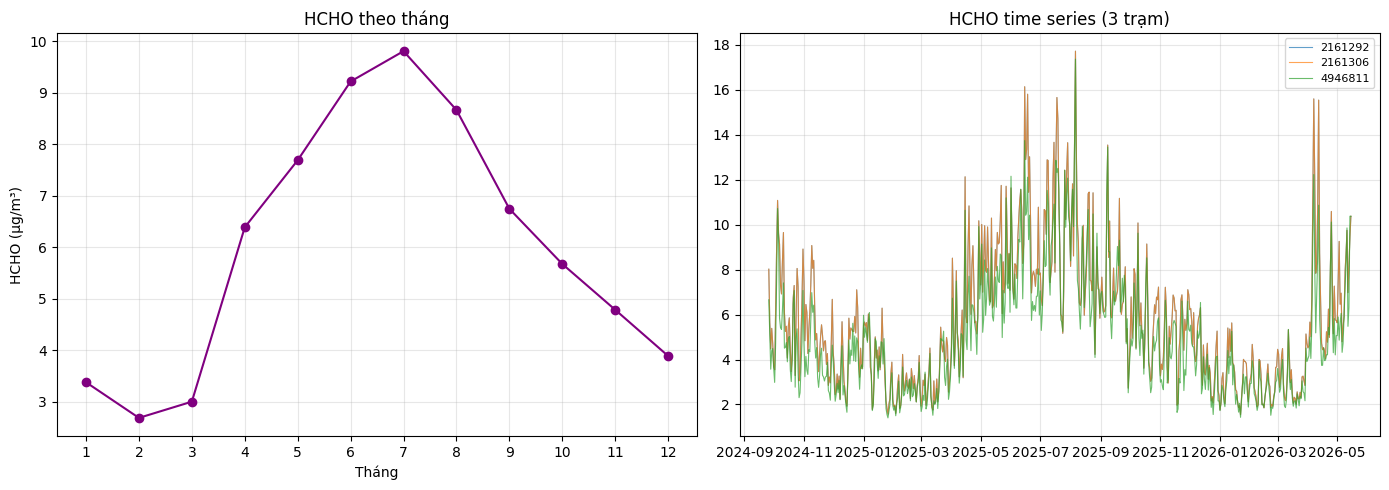

In [4]:
import matplotlib.pyplot as plt

hcho_df["month"] = pd.to_datetime(hcho_df["date"]).dt.month
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

monthly = hcho_df.groupby("month")["hcho_mean"].mean()
monthly.plot(ax=axes[0], marker="o", color="purple")
axes[0].set_title("HCHO theo tháng", fontsize=12)
axes[0].set_xlabel("Tháng"); axes[0].set_ylabel("HCHO (μg/m³)")
axes[0].set_xticks(range(1, 13)); axes[0].grid(alpha=0.3)

for loc_id in list(STATIONS.keys())[:3]:
    sub = hcho_df[hcho_df["location_id"] == loc_id]
    axes[1].plot(pd.to_datetime(sub["date"]), sub["hcho_mean"],
                 alpha=0.7, linewidth=0.8, label=str(loc_id))
axes[1].set_title("HCHO time series (3 trạm)", fontsize=12)
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / "outputs/hcho_seasonal.png", dpi=120, bbox_inches="tight")
plt.show()

## Cell 5 — Correlation HCHO vs PM2.5

Pearson r (HCHO vs PM2.5): -0.084  (n=2100)


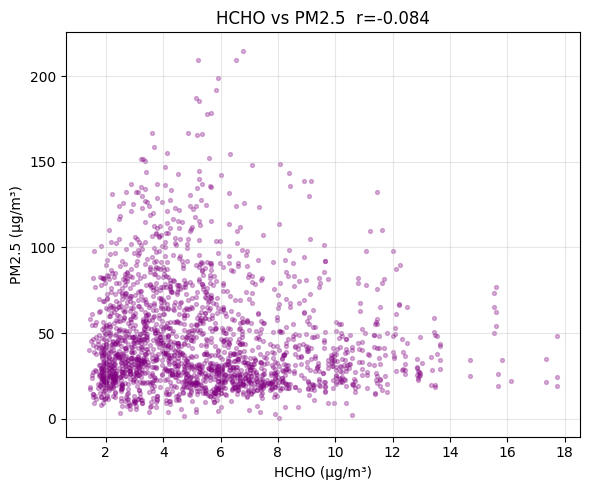

In [5]:
import matplotlib.pyplot as plt

main = pd.read_csv(MERGED, parse_dates=["date"])
hcho_df["date"] = pd.to_datetime(hcho_df["date"])

check = main.merge(hcho_df[["location_id","date","hcho_mean"]], on=["location_id","date"], how="left")
valid = check[["pm25","hcho_mean"]].dropna()
r = valid.corr().iloc[0, 1]
print(f"Pearson r (HCHO vs PM2.5): {r:.3f}  (n={len(valid)})")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(valid["hcho_mean"], valid["pm25"], alpha=0.3, s=8, color="purple")
ax.set_xlabel("HCHO (μg/m³)"); ax.set_ylabel("PM2.5 (μg/m³)")
ax.set_title(f"HCHO vs PM2.5  r={r:.3f}", fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / "outputs/hcho_correlation.png", dpi=120, bbox_inches="tight")
plt.show()

## Cell 6 — Lưu CSV + Merge vào daily_merged.csv

In [6]:
hcho_df.to_csv(OUT_CSV, index=False)
print(f"Saved: {OUT_CSV}  shape={hcho_df.shape}")

main = pd.read_csv(MERGED, parse_dates=["date"])
for col in ["hcho_mean", "hcho_max", "hcho_morning"]:
    if col in main.columns:
        main.drop(columns=[col], inplace=True)

hcho_df["date"] = pd.to_datetime(hcho_df["date"])
main = main.merge(
    hcho_df[["location_id","date","hcho_mean","hcho_max","hcho_morning"]],
    on=["location_id","date"], how="left"
)

for col in ["hcho_mean", "hcho_max", "hcho_morning"]:
    pct = main[col].notna().mean() * 100
    print(f"  {col}: {pct:.1f}% coverage")

main.to_csv(MERGED, index=False)
print(f"\nUpdated: {MERGED}  shape={main.shape}")

Saved: D:\Bussiness_plan\Multimodal_PM25\data\processed\hcho_daily.csv  shape=(5196, 6)


  hcho_mean: 81.8% coverage
  hcho_max: 81.8% coverage
  hcho_morning: 81.8% coverage



Updated: D:\Bussiness_plan\Multimodal_PM25\data\processed\daily_merged.csv  shape=(2566, 110)


## Cell 7 — Thêm vào train_3d_v2.py

```python
# ctx_feats
+ ["hcho_mean", "hcho_morning"]

# tab_cols
+ ["hcho_mean", "hcho_max", "hcho_morning"]
```

Xóa cache trước khi chạy lại:
```python
import shutil, glob, os
shutil.rmtree('outputs/final_3d_v2/cache', ignore_errors=True)
for f in glob.glob('outputs/final_3d_v2/neural_seed*.pt'): os.remove(f)
```

In [7]:
import shutil, glob, os
shutil.rmtree('outputs/final_3d_v2/cache', ignore_errors=True)
for f in glob.glob('outputs/final_3d_v2/neural_seed*.pt'): os.remove(f)